# ***Modelos de Clasificación***

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')
! ls drive/MyDrive/Colab\ Notebooks/Gestión\ de\ Proyectos/proyecto_final

Mounted at /content/drive
classification.ipynb  project_risk_raw_dataset.csv  sel_all.csv
prep_all.csv	      proyecto_final.ipynb


In [3]:
risk_dataset = pd.read_csv('drive/MyDrive/Colab Notebooks/Gestión de Proyectos/proyecto_final/project_risk_raw_dataset.csv')
risk_dataset.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


+ Quitamos variable categórica irrelevante (puedo usar los índices del DataFrame)


In [4]:
risk_dataset.drop(columns = ['Project_ID'], inplace = True)

+ Convertimos la variable target a numérica, respetando el orden lógico de las categorías


In [5]:
risk_dataset["Risk_Level"] = risk_dataset["Risk_Level"].replace({
    "Critical": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}).astype("int")

risk_dataset.Risk_Level.value_counts()

/tmp/ipython-input-3140235470.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  risk_dataset["Risk_Level"] = risk_dataset["Risk_Level"].replace({


,count
Risk_Level,
2,1396
3,1036
1,806
0,762


+ Separación *train-test*

In [6]:
from sklearn.model_selection import train_test_split

X = risk_dataset.drop('Risk_Level', axis=1)
y = risk_dataset['Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

+ Transformaciones

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


cat_cols = risk_dataset.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = risk_dataset.select_dtypes(include=[np.number]).columns.tolist()
num_cols: num_cols.remove("Risk_Level")

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)


# # Get feature names from the preprocessor
# num_features = num_cols
# cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)

# all_features = list(num_features) + list(cat_features)

# # Convert back to DataFrame
# X_train_df = pd.DataFrame(X_train_prep, columns=all_features, index=X_train.index)
# X_test_df  = pd.DataFrame(X_test_prep,  columns=all_features, index=X_test.index)


+ Aplicamos PCA conservando las componentes ortogonales que acumulan el 100% de la varianza

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=95)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca = pca.transform(X_test_prep)

## *Log-Regression básica*

              precision    recall  f1-score   support

    Critical       0.82      0.74      0.78       249
         Low       0.86      0.72      0.79       239
      Medium       0.75      0.81      0.78       424
        High       0.64      0.69      0.66       288

    accuracy                           0.75      1200
   macro avg       0.77      0.74      0.75      1200
weighted avg       0.76      0.75      0.75      1200



<Figure size 2000x2000 with 0 Axes>

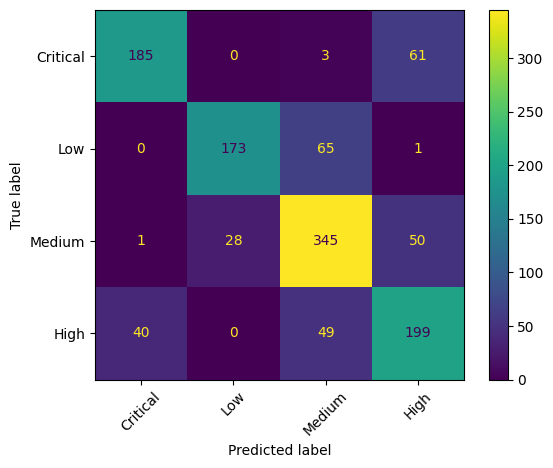


Accuracy en el set de test: 0.751667

Recall en el set de test: 0.751667


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Entrenamiento con Logistic Regression simple
clf_log = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=10000, random_state=42)
clf_log.fit(X_train_pca, y_train)

# Predicciones con la muestra de test
y_pred_log = clf_log.predict(X_test_pca)

# Accuracy y Recall en el set de test
acc_test_log = clf_log.score(X_test_pca, y_test)
recall_test_log = recall_score(y_test, y_pred_log, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_log, target_names=label_names))

# Matriz de confusión
fig = plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()

print(f"\nAccuracy en el set de test: {acc_test_log:.6f}")
print(f"\nRecall en el set de test: {recall_test_log:.6f}")

## *Log- Regression CV*

              precision    recall  f1-score   support

    Critical       0.83      0.76      0.79       249
         Low       0.84      0.75      0.79       239
      Medium       0.76      0.79      0.78       424
        High       0.65      0.71      0.68       288

    accuracy                           0.76      1200
   macro avg       0.77      0.75      0.76      1200
weighted avg       0.76      0.76      0.76      1200



<Figure size 2000x2000 with 0 Axes>

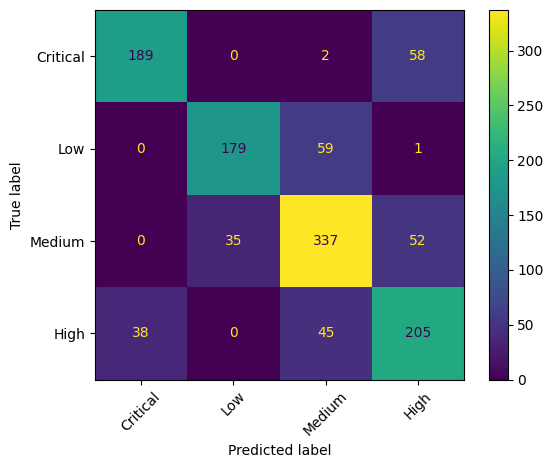


Accuracy en el set de test: 0.758333

Recall en el set de test: 0.758333


In [15]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


clf_log = LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs')
clf_log.fit(X_train_pca, y_train)

# Predicciones con la muestra de test
y_pred_log = clf_log.predict(X_test_pca)


# Accuracy y Recall en el set de test
acc_test_log = clf_log.score(X_test_pca, y_test)
recall_test_log = recall_score(y_test, y_pred_log, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_log, target_names=label_names))

# Matriz de confusión
fig = plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()

print(f"\nAccuracy en el set de test: {acc_test_log:.6f}")
print(f"\nRecall en el set de test: {recall_test_log:.6f}")

## *SVM (Kernel RBF)*

              precision    recall  f1-score   support

    Critical       0.83      0.71      0.77       249
         Low       0.82      0.72      0.77       239
      Medium       0.74      0.79      0.76       424
        High       0.64      0.70      0.67       288

    accuracy                           0.74      1200
   macro avg       0.76      0.73      0.74      1200
weighted avg       0.75      0.74      0.74      1200



<Figure size 2000x2000 with 0 Axes>

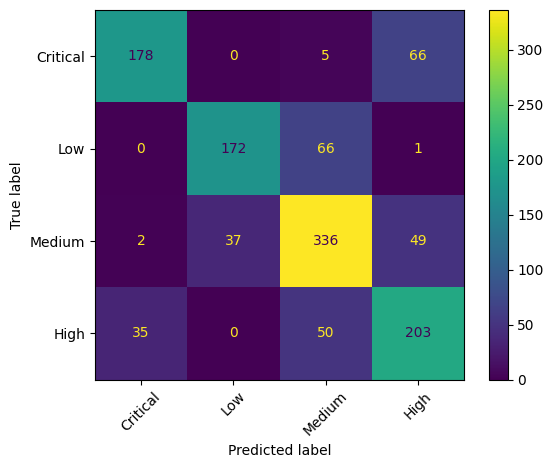


Accuracy en el set de test: 0.740833

Recall en el set de test: 0.740833


In [21]:
from sklearn.svm import SVC

clf_rbf = SVC(C=100.0, kernel='rbf', gamma=0.001, random_state=42)
clf_rbf.fit(X_train_pca, y_train)

y_pred_rbf = clf_rbf.predict(X_test_pca)

# Accuracy y Recall en el set de test
acc_test_rbf = clf_rbf.score(X_test_pca, y_test)
recall_test_rbf = recall_score(y_test, y_pred_rbf, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_rbf, target_names=label_names))

# Matriz de confusión
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()


print(f"\nAccuracy en el set de test: {acc_test_rbf:.6f}")
print(f"\nRecall en el set de test: {recall_test_rbf:.6f}")

## *LinearSVC*

              precision    recall  f1-score   support

    Critical       0.76      0.77      0.77       249
         Low       0.78      0.76      0.77       239
      Medium       0.66      0.72      0.69       424
        High       0.56      0.50      0.53       288

    accuracy                           0.68      1200
   macro avg       0.69      0.69      0.69      1200
weighted avg       0.68      0.68      0.68      1200



<Figure size 2000x2000 with 0 Axes>

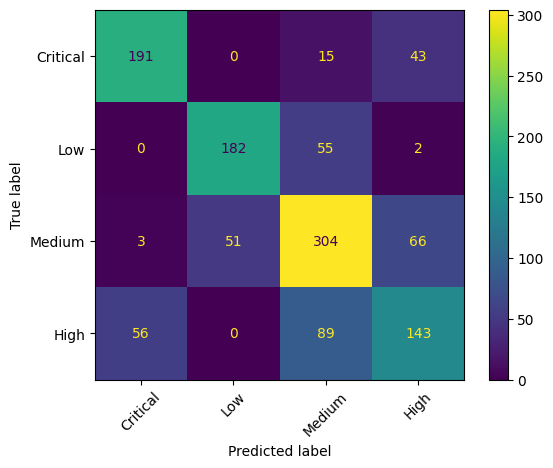


Accuracy en el set de test: 0.683333

Recall en el set de test: 0.683333


In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Entrenamiento con LinearSVC
clf_linear = LinearSVC(C=10.0, random_state=42, max_iter=10000)
clf_linear.fit(X_train_pca, y_train)

# Predicciones
y_pred_linear = clf_linear.predict(X_test_pca)

# Accuracy y Recall en el set de test
acc_test_linear = clf_linear.score(X_test_pca, y_test)
recall_test_linear = recall_score(y_test, y_pred_linear, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_linear, target_names=label_names))

# Matriz de confusión
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()

print(f"\nAccuracy en el set de test: {acc_test_linear:.6f}")
print(f"\nRecall en el set de test: {recall_test_linear:.6f}")

## *LDA*

              precision    recall  f1-score   support

    Critical       0.86      0.71      0.78       249
         Low       0.87      0.68      0.76       239
      Medium       0.72      0.83      0.77       424
        High       0.64      0.71      0.68       288

    accuracy                           0.75      1200
   macro avg       0.77      0.73      0.75      1200
weighted avg       0.76      0.75      0.75      1200



<Figure size 2000x2000 with 0 Axes>

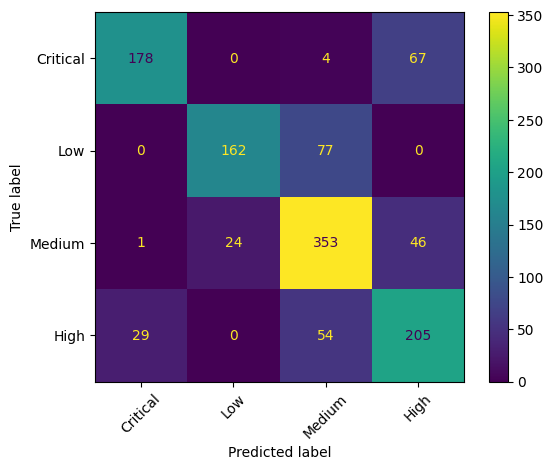


Accuracy en el set de test: 0.748333

Recall en el set de test: 0.748333


In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Entrenamiento con LDA
clf_lda = LinearDiscriminantAnalysis()
clf_lda.fit(X_train_pca, y_train)

# Predicciones con la muestra de test
y_pred_lda = clf_lda.predict(X_test_pca)

# Accuracy y Recall en el set de test
acc_test_lda = clf_lda.score(X_test_pca, y_test)
recall_test_lda = recall_score(y_test, y_pred_lda, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_lda, target_names=label_names))

# Matriz de confusión
fig = plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()

print(f"\nAccuracy en el set de test: {acc_test_lda:.6f}")
print(f"\nRecall en el set de test: {recall_test_lda:.6f}")

## *Gradient Boosting*

              precision    recall  f1-score   support

    Critical       0.69      0.43      0.53       249
         Low       0.61      0.46      0.53       239
      Medium       0.51      0.70      0.59       424
        High       0.41      0.42      0.42       288

    accuracy                           0.53      1200
   macro avg       0.56      0.50      0.51      1200
weighted avg       0.54      0.53      0.52      1200



<Figure size 2000x2000 with 0 Axes>

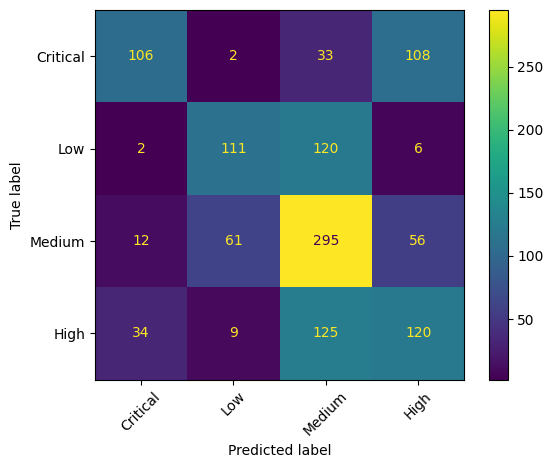


Accuracy en el set de test: 0.526667

Recall en el set de test: 0.526667


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Entrenamiento con Gradient Boosting
clf_gb = GradientBoostingClassifier(random_state=42)
clf_gb.fit(X_train_pca, y_train)

# Predicciones con la muestra de test
y_pred_gb = clf_gb.predict(X_test_pca)

# Accuracy y Recall en el set de test
acc_test_gb = clf_gb.score(X_test_pca, y_test)
recall_test_gb = recall_score(y_test, y_pred_gb, average='weighted')

# Cuadro de métricas
label_names = ["Critical", "Low", "Medium", "High"]
print(classification_report(y_test, y_pred_gb, target_names=label_names))

# Matriz de confusión
fig = plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
plt.xticks(rotation=45)
plt.show()

print(f"\nAccuracy en el set de test: {acc_test_gb:.6f}")
print(f"\nRecall en el set de test: {recall_test_gb:.6f}")